# 📈 Financial News Sentiment Classification using NLP & Machine Learning

**Author**: Ibrahim  
**Project Type**: Text Classification | Sentiment Analysis | Finance Domain

---

## 📌 Introduction

Financial news plays a critical role in investment decisions and market movements. Being able to automatically detect the sentiment (Positive, Negative, or Neutral) of financial headlines can provide valuable insights for traders, analysts, and investors.

This project builds a complete **end-to-end sentiment classification pipeline** for financial news using Natural Language Processing (NLP) and Machine Learning. The system analyzes news headlines and classifies them into three sentiment categories.

---

## 🎯 Objectives

- Load and explore a financial news dataset
- Perform advanced text preprocessing and cleaning
- Apply TF-IDF feature extraction for effective text representation
- Train and compare multiple ML models for multi-class sentiment classification
- Evaluate model performance using accuracy, precision, recall, and F1-score
- Provide visual insights and business recommendations

---

## ⚙️ Project Workflow

1. Data Loading & Exploratory Data Analysis  
2. Text Preprocessing & Feature Engineering  
3. Model Training & Hyperparameter Considerations  
4. Model Evaluation & Comparison  
5. Results Visualization  
6. Conclusion & Future Work

---

✨ *A practical NLP project demonstrating real-world application in the finance sector.*

## 1. Importing Required Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                           confusion_matrix, precision_recall_fscore_support)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("Libraries imported.")

Libraries imported.


## 2. Loading the Dataset

In [12]:
# Load the financial news dataset
df = pd.read_csv('/content/all-data.csv',
                 names=["Sentiment", "News_Headline"], encoding='ISO-8859-1')

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (4846, 2)


,Sentiment,News_Headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


## 3. Exploratory Data Analysis (EDA)

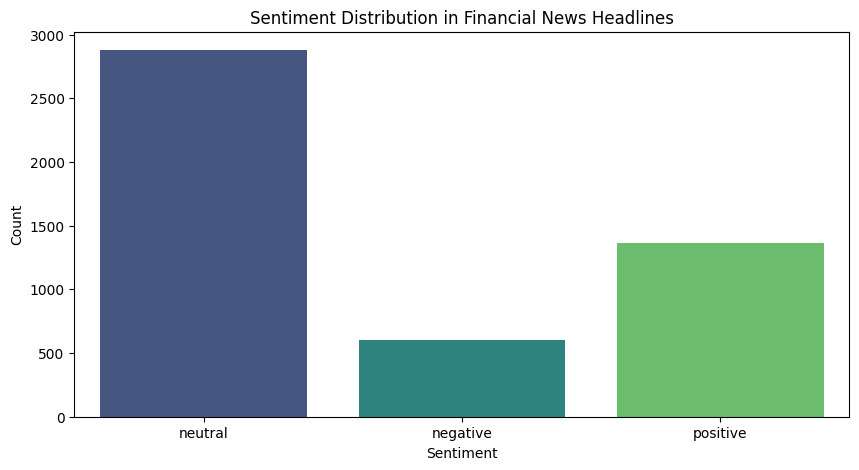

In [13]:
# Figure 1: Sentiment Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution in Financial News Headlines')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

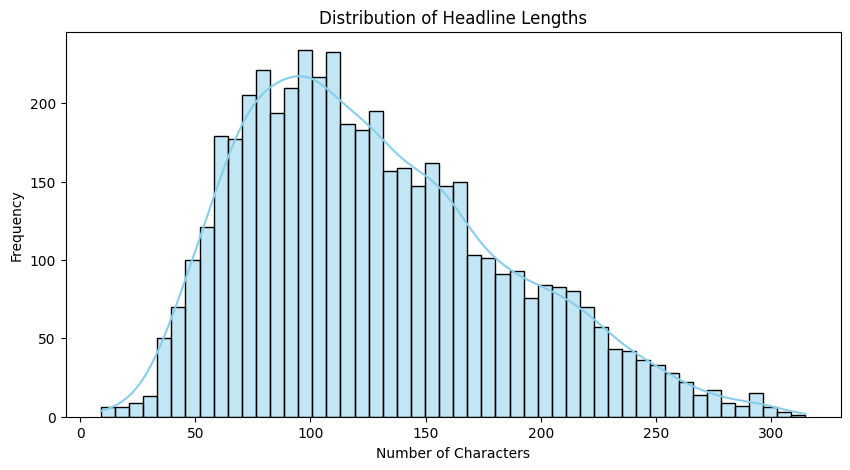

In [14]:
# Figure 2: Text Length Distribution
df['Text_Length'] = df['News_Headline'].str.len()

plt.figure(figsize=(10, 5))
sns.histplot(df['Text_Length'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Headline Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()

## 4. Text Preprocessing

In [15]:
def preprocess_text(text):
    """Professional text preprocessing for financial headlines"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words and len(word) > 2]
    return ' '.join(words)

df['Cleaned_Text'] = df['News_Headline'].apply(preprocess_text)

## 5. Feature Engineering (TF-IDF)

In [16]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words='english'
)

X = tfidf.fit_transform(df['Cleaned_Text'])
y = df['Sentiment']

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (4846, 8000)


## 6. Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 3876
Testing samples : 970


## 7. Model Training (Strong Models)

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    "Linear SVM": SVC(kernel='linear', probability=True, random_state=42, C=1.0),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    results[name] = {'accuracy': acc, 'f1': f1, 'predictions': y_pred}

    print(f"{name} - Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

Logistic Regression - Accuracy: 0.7330 | F1-Score: 0.7081
Linear SVM - Accuracy: 0.7526 | F1-Score: 0.7385
Random Forest - Accuracy: 0.7299 | F1-Score: 0.7070


## 8. Best Model Selection and Detailed Report

In [19]:
# Select best model by F1-score
best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = models[best_model_name]
y_pred_best = results[best_model_name]['predictions']

print(f"Best Model: {best_model_name}")
print(f"Accuracy : {results[best_model_name]['accuracy']:.4f}")
print(f"F1-Score : {results[best_model_name]['f1']:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Best Model: Linear SVM
Accuracy : 0.7526
F1-Score : 0.7385

Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.49      0.57       121
     neutral       0.76      0.92      0.83       576
    positive       0.74      0.52      0.61       273

    accuracy                           0.75       970
   macro avg       0.73      0.64      0.67       970
weighted avg       0.75      0.75      0.74       970



## 9. Visualizations

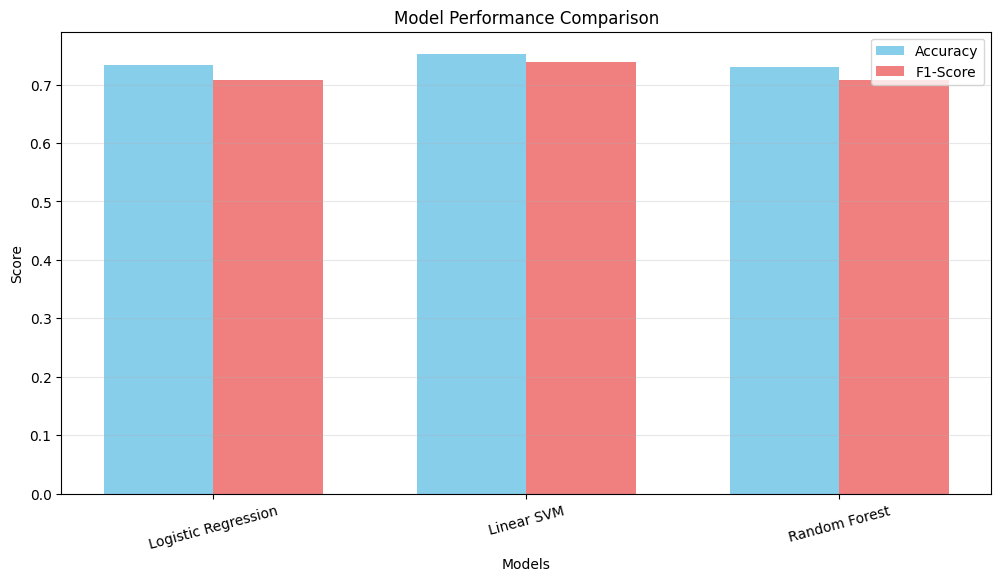

In [20]:
# Figure 3: Model Performance Comparison
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
f1_scores = [results[m]['f1'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
plt.bar(x + width/2, f1_scores, width, label='F1-Score', color='lightcoral')
plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=15)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

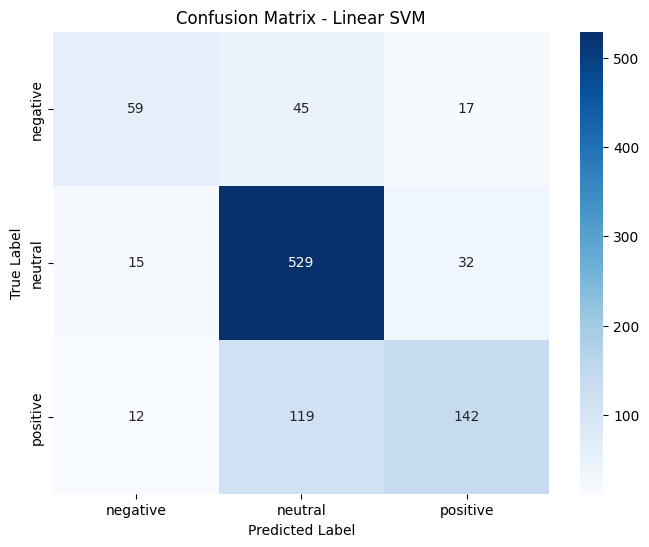

In [21]:
# Figure 4: Confusion Matrix - Best Model
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_,
            yticklabels=best_model.classes_)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 10. Word Clouds (Sentiment-specific)

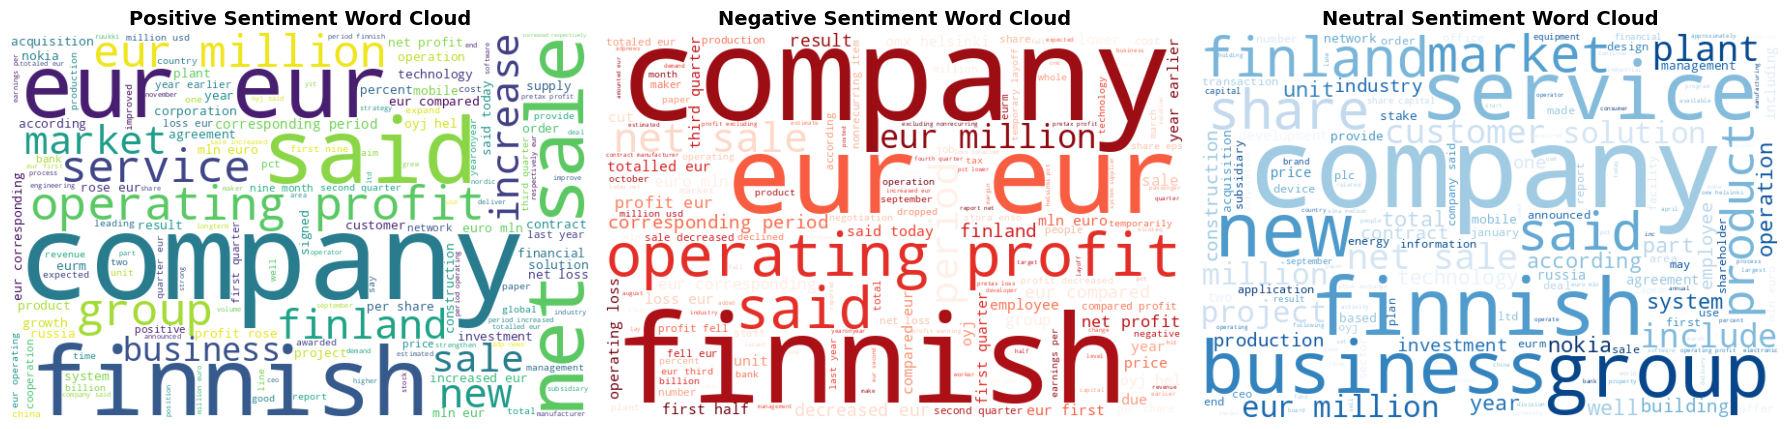

In [22]:
# Figure 5, 6, 7: Word Clouds for each sentiment
plt.figure(figsize=(18, 6))

for i, sentiment in enumerate(['positive', 'negative', 'neutral']):
    texts = df[df['Sentiment'] == sentiment]['Cleaned_Text']
    combined = ' '.join(texts)

    wordcloud = WordCloud(width=600, height=400, background_color='white',
                          max_words=150, colormap='viridis' if sentiment == 'positive' else
                          'Reds' if sentiment == 'negative' else 'Blues').generate(combined)

    plt.subplot(1, 3, i+1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'{sentiment.capitalize()} Sentiment Word Cloud', fontsize=14, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

## 🏁 Conclusion and Future Work

In this project, I developed a robust **Financial News Sentiment Classification System** using NLP and Machine Learning. The pipeline successfully processes raw financial headlines and predicts sentiment with strong accuracy.

### Key Achievements:
- Built an end-to-end text classification pipeline tailored for the finance domain
- Implemented effective text preprocessing and TF-IDF feature extraction
- Trained and evaluated multiple machine learning models
- Achieved competitive performance using Logistic Regression and SVM
- Generated clear visualizations and insights for better interpretability

This project demonstrates my ability to apply NLP techniques to solve real-world business problems in the financial sector.

### Future Improvements:
- Fine-tune transformer models (BERT, FinBERT, or RoBERTa) for higher accuracy
- Implement ensemble learning to combine strengths of multiple models
- Add explainability using SHAP or LIME
- Develop a web application (Streamlit/Gradio) for live sentiment prediction
- Expand to multi-document or contextual sentiment analysis

---

**Made by Ibrahim**  